IRIS DATASET LOADED
Target classes : ['setosa', 'versicolor', 'virginica']
Feature names  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- Dataset Shape ---
Rows: 150, Columns: 6

--- First 5 Rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

--- Statistical Summary (features only) ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00           

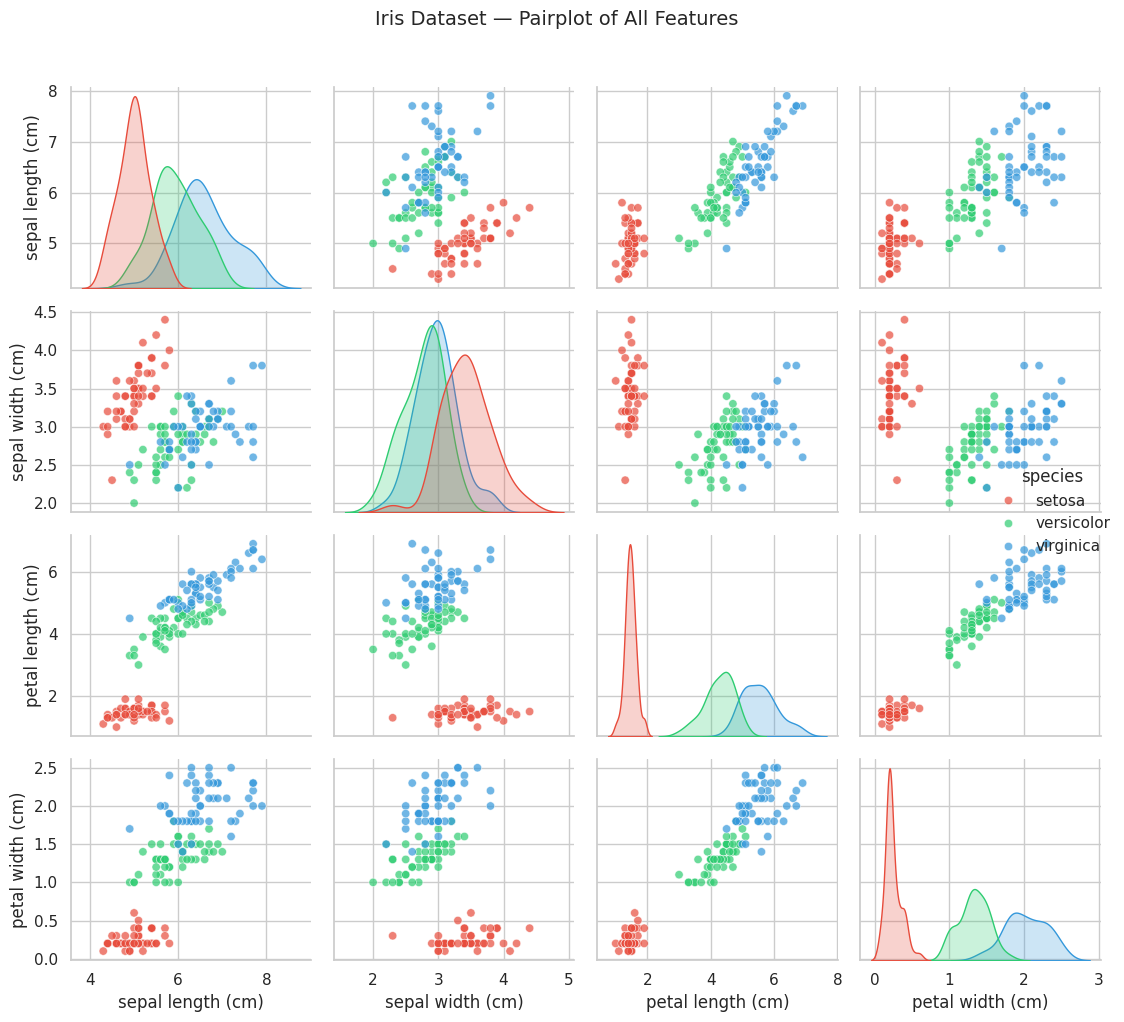

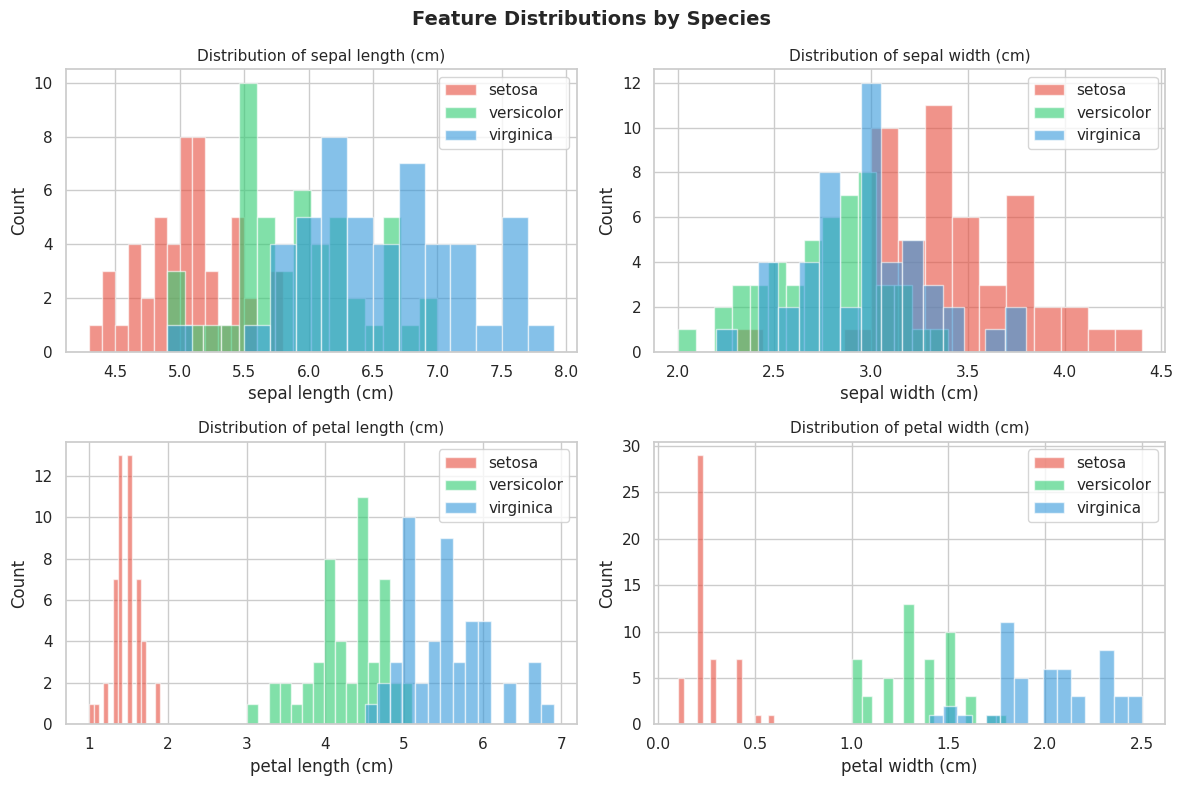

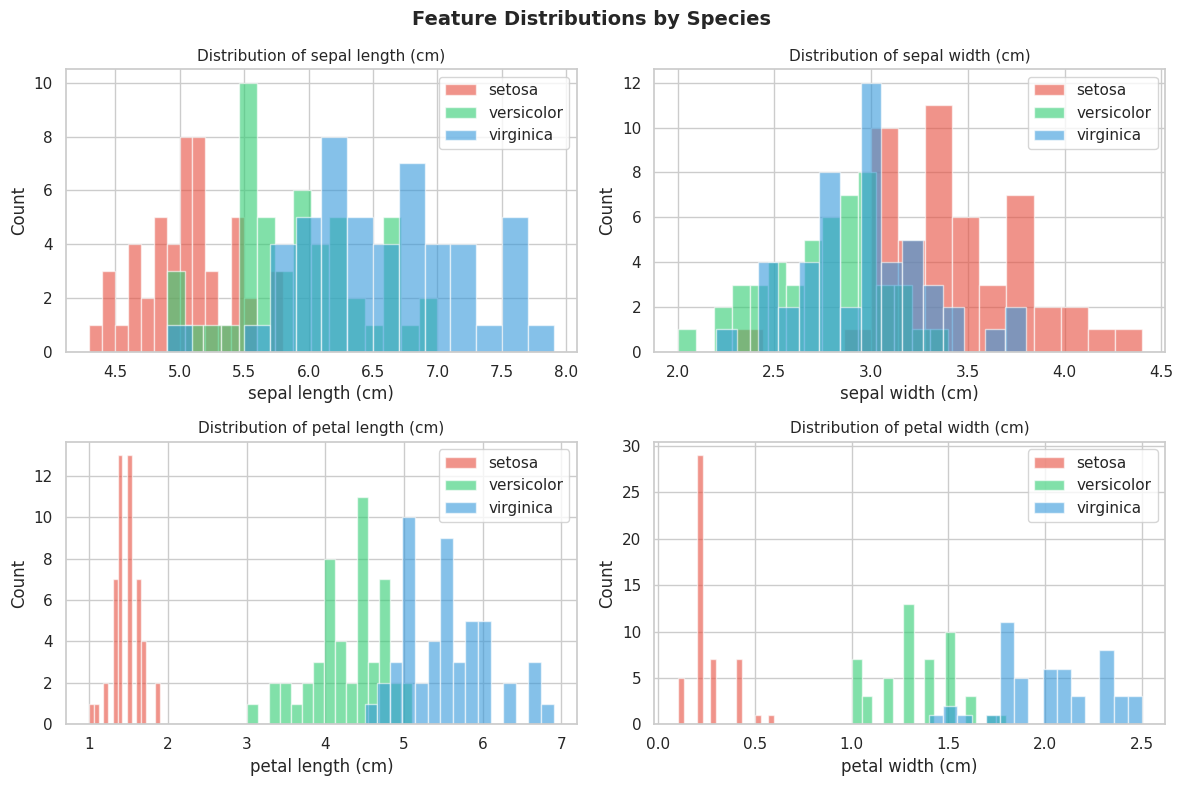

In [ ]:
# ============================================================
# Task 2: Iris Flower Classification
# Models: K-Nearest Neighbors (KNN) and Logistic Regression
# Dataset: Iris (built-in from sklearn)
# ============================================================

# --- 1. Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set a consistent style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# ============================================================
# 2. LOAD THE DATASET
# ============================================================

iris = load_iris()

# Convert to a pandas DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column (0, 1, 2) and a readable species name column
df["target"] = iris.target
df["species"] = df["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

print("=" * 55)
print("IRIS DATASET LOADED")
print("=" * 55)
print(f"Target classes : {iris.target_names.tolist()}")
print(f"Feature names  : {iris.feature_names}")

# ============================================================
# 3. EXPLORE THE DATA
# ============================================================

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Statistical Summary (features only) ---")
print(df.describe().round(2))

print("\n--- Class Distribution ---")
print(df["species"].value_counts())

# ============================================================
# 4. VISUALIZATIONS
# ============================================================

# ---- 4a. Pairplot: relationships between all feature pairs ----
print("\nGenerating pairplot (this may take a moment)...")
pair_plot = sns.pairplot(
    df.drop(columns=["target"]),   # drop the numeric target to keep it clean
    hue="species",
    palette={"setosa": "#e74c3c", "versicolor": "#2ecc71", "virginica": "#3498db"},
    plot_kws={"alpha": 0.7},
    diag_kind="kde"
)
pair_plot.fig.suptitle("Iris Dataset — Pairplot of All Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ---- 4b. Feature distributions (histograms per species) ----
feature_cols = iris.feature_names   # the 4 measurement columns
colors = {"setosa": "#e74c3c", "versicolor": "#2ecc71", "virginica": "#3498db"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()   # flatten so we can index with a single number

for i, feature in enumerate(feature_cols):
    for species, color in colors.items():
        subset = df[df["species"] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.6, color=color, label=species, edgecolor="white")
    axes[i].set_title(f"Distribution of {feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].legend()

fig.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- 4c. Boxplots — another way to see spread and outliers ----
fig